In [ ]:
import kagglehub
import os

# Download latest version
base_path = kagglehub.dataset_download("ksir0423/stationery-dataset-1")

# Adjust path to point to the actual data directory
path = os.path.join(base_path, 'Data')

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'stationery-dataset-1' dataset.
Path to dataset files: /kaggle/input/stationery-dataset-1/Data


In [ ]:
import os

print(f"Contents of base_path ({base_path}):\n{os.listdir(base_path)}")
print(f"Contents of path ({path}):\n{os.listdir(path)}")


Contents of base_path (/kaggle/input/stationery-dataset-1):
['Data']
Contents of path (/kaggle/input/stationery-dataset-1/Data):
['Test', 'Train']


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

# Check for GPU availability
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

if torch.cuda.is_available():
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")
else:
    print("No GPU found. Training will proceed on CPU, which might be slow.")

Using device: cuda:0
GPU Name: Tesla T4


### Data Loading and Preprocessing

I will now load the image dataset from the `path` obtained in the previous step and apply transformations suitable for AlexNet. AlexNet typically expects 224x224 input images.

In [ ]:
data_transforms = {
    'train': transforms.Compose([
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

# The `path` variable already points to '/kaggle/input/stationery-dataset-1/Data'.
# The inspection cell showed 'Train' and 'Test' directories inside this 'Data' folder.
actual_data_root = path

# Load the datasets, using 'Train' and 'Test' as the split names.
image_datasets = {
    'Train': datasets.ImageFolder(os.path.join(actual_data_root, 'Train'), data_transforms['train']),
    'Test': datasets.ImageFolder(os.path.join(actual_data_root, 'Test'), data_transforms['val'])
}

# Create data loaders, using 'Train' and 'Test' as the split names.
dataloaders = {
    'Train': DataLoader(image_datasets['Train'], batch_size=32, shuffle=True, num_workers=2),
    'Test': DataLoader(image_datasets['Test'], batch_size=32, shuffle=False, num_workers=2) # Shuffle False for validation/test
}

# Update dataset_sizes and class_names with 'Train' and 'Test'
dataset_sizes = {x: len(image_datasets[x]) for x in ['Train', 'Test']}
class_names = image_datasets['Train'].classes

print(f"Number of training samples: {dataset_sizes['Train']}")
print(f"Number of validation samples: {dataset_sizes['Test']}")
print(f"Classes: {class_names}")

Number of training samples: 1289
Number of validation samples: 485
Classes: ['Ballpoint pen', 'Fountain pen', 'Pencil']


### AlexNet Model Definition and Training

I will load a pre-trained AlexNet model from `torchvision`, modify its final classification layer to match the number of classes in our dataset, and then set up the training loop to utilize the GPU.

In [ ]:
# Load pre-trained AlexNet model
model = models.alexnet(weights=models.AlexNet_Weights.DEFAULT)

# Modify the last layer for our number of classes
num_ftrs = model.classifier[6].in_features
model.classifier[6] = nn.Linear(num_ftrs, len(class_names))

# Move model to GPU if available
model = model.to(device)

# Define loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.001, momentum=0.9)

# Training function
def train_model(model, criterion, optimizer, num_epochs=10):
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    for epoch in range(num_epochs):
        print(f'Epoch {epoch}/{num_epochs - 1}')
        print('-' * 10)

        # Use 'Train' and 'Test' as phases to match the dataloaders keys
        for phase_key in ['Train', 'Test']:
            if phase_key == 'Train':
                model.train()  # Set model to training mode
            else:
                model.eval()   # Set model to evaluate mode

            running_loss = 0.0
            running_corrects = 0

            # Iterate over data.
            for inputs, labels in dataloaders[phase_key]:
                inputs = inputs.to(device)
                labels = labels.to(device)

                # zero the parameter gradients
                optimizer.zero_grad()

                # forward
                # track history if only in train
                with torch.set_grad_enabled(phase_key == 'Train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    # backward + optimize only if in training phase
                    if phase_key == 'Train':
                        loss.backward()
                        optimizer.step()

                # statistics
                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            epoch_loss = running_loss / dataset_sizes[phase_key]
            epoch_acc = running_corrects.double() / dataset_sizes[phase_key]

            # Map 'Train' to 'train' for history recording, 'Test' to 'val'
            history_phase = 'train' if phase_key == 'Train' else 'val'

            print(f'{history_phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')
            history[f'{history_phase}_loss'].append(epoch_loss)
            history[f'{history_phase}_acc'].append(epoch_acc.item())

    print('Training complete')
    return model, history

# Start training
model_ft, training_history = train_model(model, criterion, optimizer, num_epochs=10) # Reduced epochs for demonstration

Epoch 0/9
----------
train Loss: 0.7004 Acc: 0.6757
val Loss: 0.9972 Acc: 0.6804
Epoch 1/9
----------
train Loss: 0.5391 Acc: 0.7711
val Loss: 0.7978 Acc: 0.7979
Epoch 2/9
----------
train Loss: 0.4557 Acc: 0.8130
val Loss: 0.6969 Acc: 0.7753
Epoch 3/9
----------
train Loss: 0.4088 Acc: 0.8216
val Loss: 0.7521 Acc: 0.8021
Epoch 4/9
----------
train Loss: 0.3909 Acc: 0.8479
val Loss: 0.8155 Acc: 0.8309
Epoch 5/9
----------
train Loss: 0.3901 Acc: 0.8472
val Loss: 0.7645 Acc: 0.8021
Epoch 6/9
----------
train Loss: 0.3722 Acc: 0.8456
val Loss: 1.1729 Acc: 0.8330
Epoch 7/9
----------
train Loss: 0.3721 Acc: 0.8456
val Loss: 0.9314 Acc: 0.8144
Epoch 8/9
----------
train Loss: 0.3233 Acc: 0.8565
val Loss: 0.9853 Acc: 0.8268
Epoch 9/9
----------
train Loss: 0.3580 Acc: 0.8650
val Loss: 0.8742 Acc: 0.8495
Training complete


### Summarize Training Results

Here is a summary of the training performance, showing the final loss and accuracy for both the training and validation sets.

In [ ]:
print("\n--- Training Summary ---")
final_train_loss = training_history['train_loss'][-1]
final_train_acc = training_history['train_acc'][-1]
final_val_loss = training_history['val_loss'][-1]
final_val_acc = training_history['val_acc'][-1]

print(f"Final Training Loss: {final_train_loss:.4f}")
print(f"Final Training Accuracy: {final_train_acc:.4f}")
print(f"Final Validation Loss: {final_val_loss:.4f}")
print(f"Final Validation Accuracy: {final_val_acc:.4f}")


--- Training Summary ---
Final Training Loss: 0.3580
Final Training Accuracy: 0.8650
Final Validation Loss: 0.8742
Final Validation Accuracy: 0.8495


### Training Plots

These plots visualize the training and validation loss and accuracy over each epoch, which helps in understanding the model's learning process and identifying potential overfitting or underfitting.

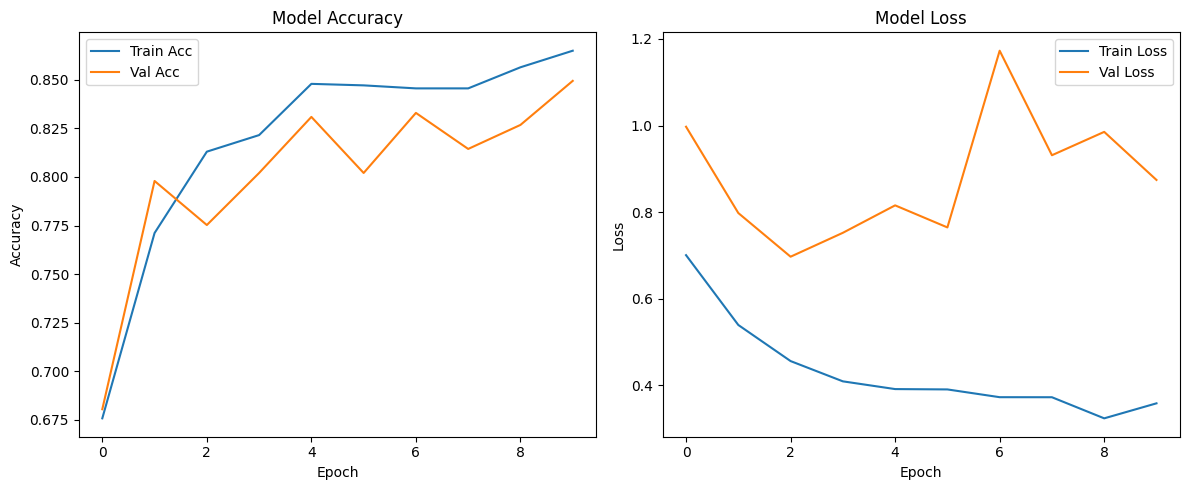

In [ ]:
epochs = range(len(training_history['train_loss']))

plt.figure(figsize=(12, 5))

# Plot training & validation accuracy values
plt.subplot(1, 2, 1)
plt.plot(epochs, training_history['train_acc'], label='Train Acc')
plt.plot(epochs, training_history['val_acc'], label='Val Acc')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(epochs, training_history['train_loss'], label='Train Loss')
plt.plot(epochs, training_history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()